# experiment_v2_two_layer_attention.ipynb

Two-layer attention (SA + CA) variant of the bootstrap experiment.
Uses `CytokineABMIL_V2` with `TwoLayerAttentionModule` instead of the
standard single-layer `CytokineABMIL`.

Cytokine sampling mirrors `experiment_bootstrap.ipynb` exactly:
- Same `BOOTSTRAP_SEED`, `SIMPLE_POOL`, `COMPLEX_POOL`.
- Same `VAL_DONORS = ["Donor2", "Donor3"]`.
- Adds a **Layer Specialization Analysis** section at the end.

Pre-registered hypothesis: simple cytokines rank higher in learnability AUC
than complex cytokines (one-sided Mann-Whitney U, never re-tested).

In [1]:
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from scipy.stats import mannwhitneyu, spearmanr

from cytokine_mil.data.dataset import CellDataset, PseudoTubeDataset
from cytokine_mil.data.label_encoder import CytokineLabel
from cytokine_mil.training.train_encoder import train_encoder
from cytokine_mil.training.train_mil import train_mil
from cytokine_mil.experiment_setup import (
    build_stage1_manifest,
    filter_manifest,
    split_manifest_by_donor,
    build_encoder,
)
from cytokine_mil.models.two_layer_attention import TwoLayerAttentionModule
from cytokine_mil.models.cytokine_abmil_v2 import CytokineABMIL_V2
from cytokine_mil.analysis.dynamics import (
    aggregate_to_donor_level,
    rank_cytokines_by_learnability,
    compute_cytokine_entropy_summary,
    compute_confusion_entropy_summary,
)
from torch.utils.data import DataLoader

## Top-level controls

In [2]:
BOOTSTRAP_SEED     = 42   # Controls which 5+5 cytokines are sampled from the pools.
N_SAMPLE_PER_GROUP = 5

CONFIG_PATH   = "cytokines/cytokines-mil/configs/default.yaml"
MANIFEST_PATH = "/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/manifest.json"
HVG_PATH      = "/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/hvg_list.json"

VAL_DONORS = ["Donor2", "Donor3"]

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

with open(HVG_PATH) as f:
    gene_names = json.load(f)

print(f"Bootstrap seed:  {BOOTSTRAP_SEED}  (controls cytokine sampling)")
print(f"Val donors:      {VAL_DONORS}")
print(f"Config:          {cfg}")

Bootstrap seed:  42  (controls cytokine sampling)
Val donors:      ['Donor2', 'Donor3']
Config:          {'data': {'manifest_path': '/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/manifest.json', 'n_hvgs': 4000, 'n_per_cell_type': 30, 'min_cells_threshold': 10, 'n_pseudo_tubes': 10}, 'model': {'embedding_dim': 128, 'attention_hidden_dim': 64, 'n_classes': 91}, 'training': {'stage1_epochs': 50, 'stage2_epochs': 100, 'stage3_epochs': 50, 'optimizer': 'sgd', 'momentum': 0.9, 'lr': 0.01, 'lr_scheduler': None, 'lr_warmup_epochs': 5}, 'dynamics': {'log_every_n_epochs': 1, 'random_seeds': [42, 123, 7]}}


## Load manifest

In [3]:
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

manifest_cytokines = {e["cytokine"] for e in manifest}
print(f"Total manifest entries: {len(manifest)}")
print(f"Unique cytokines:       {len(manifest_cytokines)}")

Total manifest entries: 10920
Unique cytokines:       91


## Cytokine pools

Name corrections: IL-1β → `IL-1-beta`, IFN-β → `IFN-beta`, IL-32β → `IL-32-beta`, TGF-β → `TGF-beta1`.

In [4]:
SIMPLE_POOL = [
    "IL-4", "IL-10", "IL-2", "M-CSF", "TNF-alpha",
    "IL-1-beta", "IFN-beta", "IL-7", "G-CSF",
]

COMPLEX_POOL = [
    "IL-12", "IL-32-beta", "OSM", "IL-22", "VEGF",
    "HGF", "TGF-beta1", "IL-6",
]

missing_simple  = [c for c in SIMPLE_POOL  if c not in manifest_cytokines]
missing_complex = [c for c in COMPLEX_POOL if c not in manifest_cytokines]
if missing_simple or missing_complex:
    print(f"WARNING — missing from manifest: simple={missing_simple}  complex={missing_complex}")
else:
    print(f"Simple pool  ({len(SIMPLE_POOL)}): {SIMPLE_POOL}")
    print(f"Complex pool ({len(COMPLEX_POOL)}): {COMPLEX_POOL}")

Simple pool  (9): ['IL-4', 'IL-10', 'IL-2', 'M-CSF', 'TNF-alpha', 'IL-1-beta', 'IFN-beta', 'IL-7', 'G-CSF']
Complex pool (8): ['IL-12', 'IL-32-beta', 'OSM', 'IL-22', 'VEGF', 'HGF', 'TGF-beta1', 'IL-6']


## Bootstrap sampling

Sampling is seeded by `BOOTSTRAP_SEED`.

In [5]:
# BOOTSTRAP_SEED is defined in the top-level controls cell above.
_rng = random.Random(BOOTSTRAP_SEED)
SIMPLE_CYTOKINES  = sorted(_rng.sample(SIMPLE_POOL,  N_SAMPLE_PER_GROUP))
COMPLEX_CYTOKINES = sorted(_rng.sample(COMPLEX_POOL, N_SAMPLE_PER_GROUP))
SUBSET_CYTOKINES  = SIMPLE_CYTOKINES + COMPLEX_CYTOKINES

print(f"Bootstrap seed:  {BOOTSTRAP_SEED}")
print(f"SIMPLE:  {SIMPLE_CYTOKINES}")
print(f"COMPLEX: {COMPLEX_CYTOKINES}")
print(f"Total subset (excl. PBS): {len(SUBSET_CYTOKINES)}")

Bootstrap seed:  42
SIMPLE:  ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4']
COMPLEX: ['HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']
Total subset (excl. PBS): 10


## Filter manifest to subset

In [6]:
subset_manifest = filter_manifest(manifest, SUBSET_CYTOKINES, include_pbs=True)

label_encoder = CytokineLabel().fit(subset_manifest)
LABEL_ENCODER_PATH = str(
    Path(MANIFEST_PATH).parent / f"label_encoder_v2_bootstrap_{BOOTSTRAP_SEED}.json"
)
label_encoder.save(LABEL_ENCODER_PATH)

train_manifest, val_manifest = split_manifest_by_donor(subset_manifest, val_donors=VAL_DONORS)

SUBSET_MANIFEST_PATH = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}.json")
TRAIN_MANIFEST_PATH  = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}_train.json")
VAL_MANIFEST_PATH    = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}_val.json")

with open(SUBSET_MANIFEST_PATH, "w") as f:
    json.dump(subset_manifest, f)
with open(TRAIN_MANIFEST_PATH, "w") as f:
    json.dump(train_manifest, f)
with open(VAL_MANIFEST_PATH, "w") as f:
    json.dump(val_manifest, f)

print(f"Subset entries: {len(subset_manifest)}  (train: {len(train_manifest)}, val: {len(val_manifest)})")

Subset entries: 1320  (train: 1100, val: 220)


## Stage 1 manifest (one tube per cytokine for encoder pre-training)

In [7]:
STAGE1_MANIFEST_PATH = str(
    Path(MANIFEST_PATH).parent / f"manifest_stage1_v2_bootstrap_{BOOTSTRAP_SEED}.json"
)
_stage1_manifest = build_stage1_manifest(train_manifest, save_path=STAGE1_MANIFEST_PATH)
print(f"Stage 1 manifest entries: {len(_stage1_manifest)}")

Stage 1 manifest entries: 11


## Stage 1 — shared encoder pre-training (cell-type classification)

In [8]:
cell_dataset = CellDataset(STAGE1_MANIFEST_PATH, gene_names=gene_names, preload=True)
cell_loader  = DataLoader(cell_dataset, batch_size=256, shuffle=True, num_workers=0)

n_cell_types = cell_dataset.n_cell_types()
n_genes      = len(gene_names)

encoder = build_encoder(
    n_input_genes=n_genes,
    n_cell_types=n_cell_types,
    embed_dim=cfg["model"]["embedding_dim"],
)

encoder = train_encoder(
    encoder, cell_loader,
    # n_epochs=cfg["training"]["stage1_epochs"],
    n_epochs=8,
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    verbose=True,
)

torch.save(encoder.state_dict(), f"encoder_stage1_v2_bootstrap_{BOOTSTRAP_SEED}.pt")
print("Stage 1 complete.")

[Stage 1] Epoch   1/8 | loss=2.3655 | acc=0.3376


[Stage 1] Epoch   2/8 | loss=0.5446 | acc=0.7956


[Stage 1] Epoch   3/8 | loss=0.3091 | acc=0.8858


[Stage 1] Epoch   4/8 | loss=0.2150 | acc=0.9225


[Stage 1] Epoch   5/8 | loss=0.1505 | acc=0.9503


[Stage 1] Epoch   6/8 | loss=0.1013 | acc=0.9728


[Stage 1] Epoch   7/8 | loss=0.0706 | acc=0.9830


[Stage 1] Epoch   8/8 | loss=0.0427 | acc=0.9942
Stage 1 complete.


## Build datasets for Stage 2

In [9]:
train_dataset = PseudoTubeDataset(TRAIN_MANIFEST_PATH, label_encoder)
val_dataset   = PseudoTubeDataset(VAL_MANIFEST_PATH,   label_encoder)

print(f"Train tubes: {len(train_dataset)}")
print(f"Val tubes:   {len(val_dataset)}")

Train tubes: 1100
Val tubes:   220


## Build CytokineABMIL_V2 (two-layer attention, frozen encoder)

In [10]:
attention = TwoLayerAttentionModule(
    embed_dim=cfg["model"]["embedding_dim"],
    attention_hidden_dim=cfg["model"]["attention_hidden_dim"],
)

mil_model = CytokineABMIL_V2(
    encoder=encoder,
    attention=attention,
    n_classes=label_encoder.n_classes(),
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_frozen=True,
)

print(mil_model)

CytokineABMIL_V2(
  (encoder): InstanceEncoder(
    (input_proj): Sequential(
      (0): Linear(in_features=4000, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
    )
    (res1): _ResBlock(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=512, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=512, bias=True)
      (act): GELU(approximate='none')
    )
    (down1): _DownBlock(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=512, out_features=256, bias=True)
      (fc2): Linear(in_features=256, out_features=256, bias=True)
      (skip): Linear(in_features=512, out_features=256, bias=False)
      (act): GELU(approximate='none')
    )
    (res2): _ResBlock(
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=256, out_features=256, 

## Stage 2 — MIL training (frozen encoder)

In [11]:
dynamics_stage2 = train_mil(
    mil_model,
    train_dataset,
    # n_epochs=cfg["training"]["stage2_epochs"],
    n_epochs=40,
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    lr_scheduler=cfg["training"]["lr_scheduler"],
    lr_warmup_epochs=cfg["training"]["lr_warmup_epochs"],
    log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
    seed=BOOTSTRAP_SEED,
    verbose=True,
    val_dataset=val_dataset,
)

torch.save(mil_model.state_dict(), f"mil_stage2_v2_bootstrap_{BOOTSTRAP_SEED}.pt")

print(f"Train records: {len(dynamics_stage2['records'])}")
print(f"Val records:   {len(dynamics_stage2['val_records'])}")

[Stage 2/3] Epoch   1/40 | loss=1.6996


[Stage 2/3] Epoch   2/40 | loss=0.8682


[Stage 2/3] Epoch   3/40 | loss=0.7312


[Stage 2/3] Epoch   4/40 | loss=0.6228


[Stage 2/3] Epoch   5/40 | loss=0.5829


...

[Stage 2/3] Epoch  36/40 | loss=0.0011


[Stage 2/3] Epoch  37/40 | loss=0.0011


[Stage 2/3] Epoch  38/40 | loss=0.0010


[Stage 2/3] Epoch  39/40 | loss=0.0010


[Stage 2/3] Epoch  40/40 | loss=0.0009
Train records: 1100
Val records:   220


## Stage 3 — optional fine-tuning (unfrozen encoder)

In [12]:
# mil_model.unfreeze_encoder()

# dynamics_stage3 = train_mil(
#     mil_model,
#     train_dataset,
#     n_epochs=cfg["training"]["stage3_epochs"],
#     lr=cfg["training"]["lr"] * 0.1,
#     momentum=cfg["training"]["momentum"],
#     log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
#     seed=BOOTSTRAP_SEED,
#     verbose=True,
#     val_dataset=val_dataset,
# )

# torch.save(mil_model.state_dict(), f"mil_stage3_v2_bootstrap_{BOOTSTRAP_SEED}.pt")
# print("Stage 3 complete.")

## Learnability ranking (Stage 2)

Metric: `AUC(mean_donor_p_correct_trajectory)` — median across pseudo-tubes per donor, then mean across donors.

In [13]:
donor_traj     = aggregate_to_donor_level(dynamics_stage2["records"])
val_donor_traj = aggregate_to_donor_level(dynamics_stage2["val_records"])

ranking_result     = rank_cytokines_by_learnability(donor_traj,     exclude=["PBS"])
val_ranking_result = rank_cytokines_by_learnability(val_donor_traj, exclude=["PBS"])

print(ranking_result["metric_description"])
print()
print(f"{'Cytokine':<20} {'Group':<10} {'AUC (train)':<14} {'AUC (val)'}")
print("-" * 60)

val_auc_map = dict(val_ranking_result["ranking"])
for cytokine, auc in ranking_result["ranking"]:
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    val_auc = val_auc_map.get(cytokine, float("nan"))
    print(f"{cytokine:<20} {group:<10} {auc:<14.4f} {val_auc:.4f}")

AUC of mean p_correct_trajectory across pseudo-tubes, aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

Cytokine             Group      AUC (train)    AUC (val)
------------------------------------------------------------
IL-32-beta           COMPLEX    38.6204        38.5345
IL-4                 SIMPLE     38.4423        30.1727
IL-2                 SIMPLE     37.8066        19.7693
IL-1-beta            SIMPLE     37.5668        18.5343
IL-10                SIMPLE     37.5033        19.9720
IL-12                COMPLEX    36.2028        4.5902
G-CSF                SIMPLE     33.9221        0.5198
IL-22                COMPLEX    33.8493        0.2965
VEGF                 COMPLEX    33.7434        0.9863
HGF                  COMPLEX    32.0496        0.1682


## Learning curves — Stage 2 (train vs val)

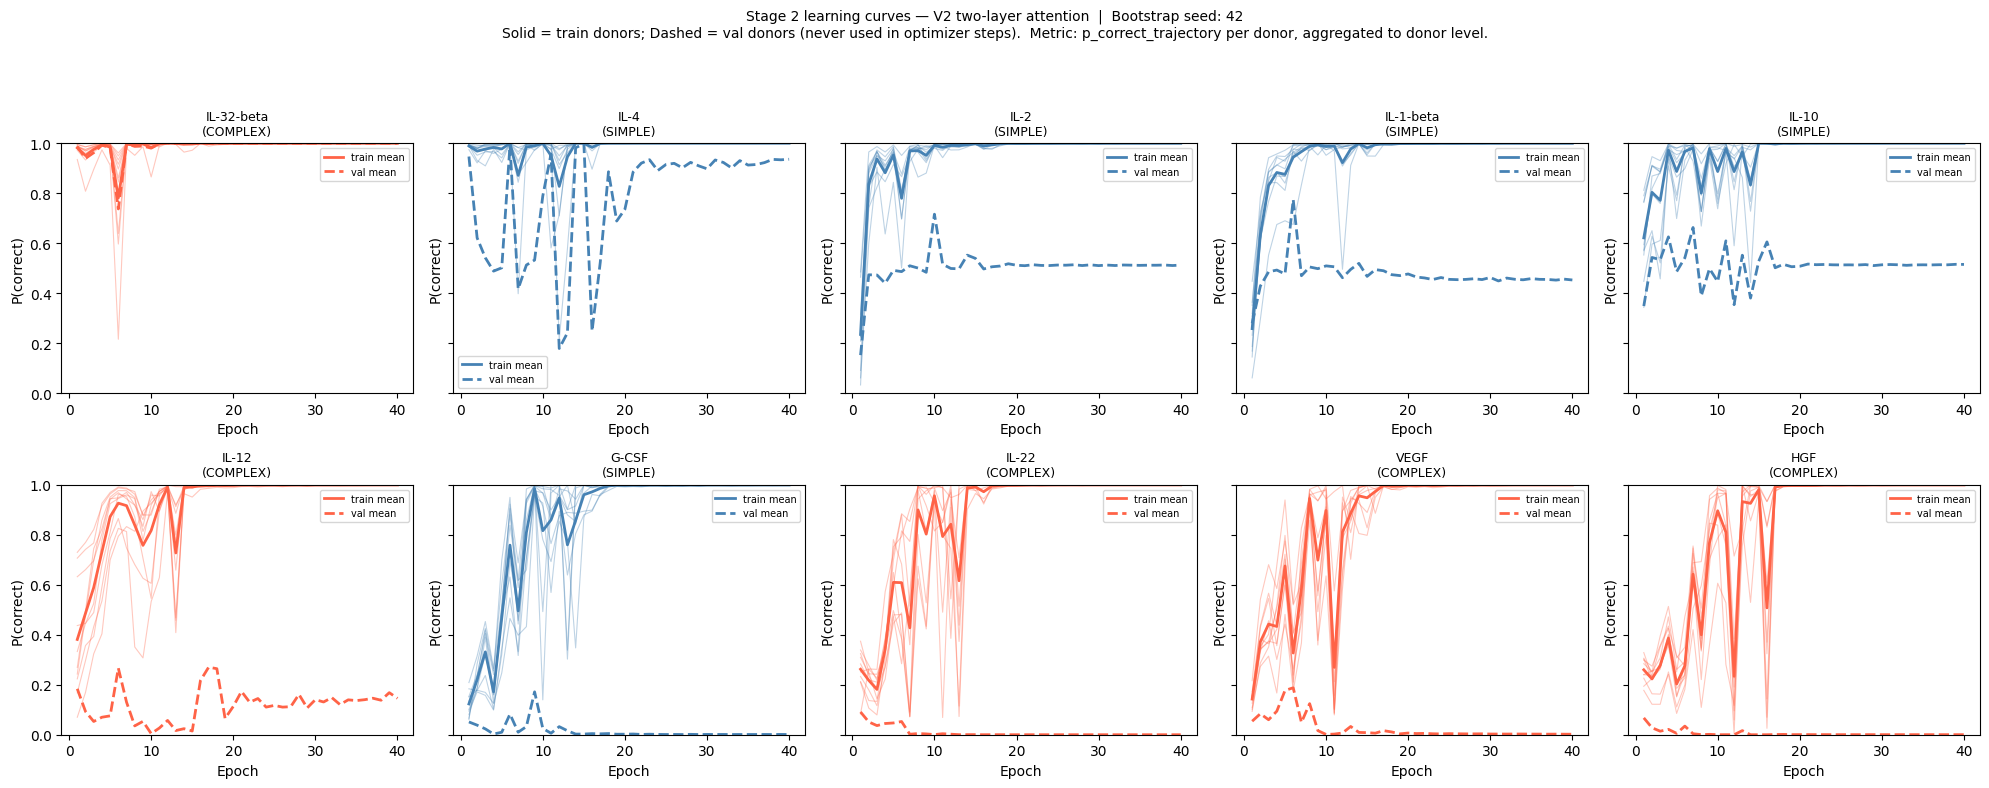

In [14]:
GROUP_COLOR = {"SIMPLE": "steelblue", "COMPLEX": "tomato"}

epochs = dynamics_stage2["logged_epochs"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for ax, (cytokine, _auc) in zip(axes, ranking_result["ranking"]):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    color = GROUP_COLOR[group]

    # Train
    if cytokine in donor_traj:
        for _donor, traj in donor_traj[cytokine].items():
            ax.plot(epochs, traj, alpha=0.35, color=color, linewidth=0.8)
        mean_traj = np.mean(list(donor_traj[cytokine].values()), axis=0)
        ax.plot(epochs, mean_traj, color=color, linewidth=2, label="train mean")

    # Val
    if cytokine in val_donor_traj:
        val_mean = np.mean(list(val_donor_traj[cytokine].values()), axis=0)
        ax.plot(epochs, val_mean, color=color, linewidth=2, linestyle="--", label="val mean")

    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("P(correct)")
    ax.legend(fontsize=7)

fig.suptitle(
    f"Stage 2 learning curves — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Solid = train donors; Dashed = val donors (never used in optimizer steps)."
    "  Metric: p_correct_trajectory per donor, aggregated to donor level.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"learning_curves_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

## Attention entropy summary

In [15]:
entropy_result     = compute_cytokine_entropy_summary(dynamics_stage2["records"])
val_entropy_result = compute_cytokine_entropy_summary(dynamics_stage2["val_records"])

print(entropy_result["metric_description"])
print()
for cytokine, vals in sorted(
    entropy_result["summary"].items(), key=lambda x: x[1]["mean_entropy"], reverse=True
):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    print(f"{cytokine:<20} {group:<10} H={vals['mean_entropy']:.4f} +/- {vals['std_entropy']:.4f}")

mean across epochs and pseudo-tubes of H(attention_weights) = -sum_i a_i * log(a_i), aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

IL-12                COMPLEX    H=3.6470 +/- 0.3172
IL-1-beta            SIMPLE     H=3.5508 +/- 0.1051
IL-2                 SIMPLE     H=3.4020 +/- 0.3831
HGF                  COMPLEX    H=3.2596 +/- 0.6790
IL-4                 SIMPLE     H=3.1911 +/- 0.3780
IL-32-beta           COMPLEX    H=2.8708 +/- 0.1071
IL-10                SIMPLE     H=2.8577 +/- 0.7235
VEGF                 COMPLEX    H=2.7355 +/- 0.7542
G-CSF                SIMPLE     H=2.7199 +/- 0.8381
IL-22                COMPLEX    H=2.5928 +/- 1.0357
PBS                  COMPLEX    H=1.9166 +/- 0.2864


## Confusion entropy summary

In [16]:
confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["confusion_entropy_trajectory"], exclude=["PBS"]
)
val_confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["val_confusion_entropy_trajectory"], exclude=["PBS"]
)

print(confusion_result["metric_description"])
print()
val_confusion_map = dict(val_confusion_result["ranking"])
for cytokine, auc in confusion_result["ranking"]:
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    val_v = val_confusion_map.get(cytokine, float("nan"))
    print(f"{cytokine:<20} {group:<10} AUC(H_confusion) train={auc:.4f}  val={val_v:.4f}")

AUC of H_confusion(C,t) = -sum_{k!=C} q_k(t) * log(q_k(t)), where q_k(t) is the renormalized off-diagonal mean softmax score across all pseudo-tubes of cytokine C at epoch t. Low = confusion concentrated on similar cytokines (similarity confound). High = confusion spread randomly (genuine difficulty).

IL-22                COMPLEX    AUC(H_confusion) train=71.9395  val=55.0424
G-CSF                SIMPLE     AUC(H_confusion) train=65.9390  val=46.5423
VEGF                 COMPLEX    AUC(H_confusion) train=63.5907  val=48.0705
IL-1-beta            SIMPLE     AUC(H_confusion) train=63.4844  val=15.7178
HGF                  COMPLEX    AUC(H_confusion) train=60.9354  val=42.3177
IL-12                COMPLEX    AUC(H_confusion) train=59.4053  val=42.3320
IL-4                 SIMPLE     AUC(H_confusion) train=55.2355  val=37.4901
IL-32-beta           COMPLEX    AUC(H_confusion) train=54.0064  val=41.7701
IL-10                SIMPLE     AUC(H_confusion) train=53.4837  val=36.9212
IL-2        

## Pre-registered hypothesis test

One-sided Mann-Whitney U: SIMPLE AUC > COMPLEX AUC (5 vs 5, donor-aggregated).
**Never repeated after unblinding.**

In [17]:
auc_map = dict(ranking_result["ranking"])

simple_aucs  = [auc_map[c] for c in SIMPLE_CYTOKINES  if c in auc_map]
complex_aucs = [auc_map[c] for c in COMPLEX_CYTOKINES if c in auc_map]

stat, p_value = mannwhitneyu(simple_aucs, complex_aucs, alternative="greater")

# Rank-biserial correlation r = 1 - 2*U / (n1*n2)
n1, n2 = len(simple_aucs), len(complex_aucs)
rbc = 1 - 2 * stat / (n1 * n2)

print(f"Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"SIMPLE  AUCs: {[round(v, 4) for v in simple_aucs]}")
print(f"COMPLEX AUCs: {[round(v, 4) for v in complex_aucs]}")
print(f"Mann-Whitney U = {stat:.1f}  |  p (one-sided) = {p_value:.4f}")
print(f"Rank-biserial r = {rbc:.4f}  (low power: n=5 per group)")
print()
print("  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.")

Bootstrap seed: 42
SIMPLE  AUCs: [33.9221, 37.5668, 37.5033, 37.8066, 38.4423]
COMPLEX AUCs: [32.0496, 36.2028, 33.8493, 38.6204, 33.7434]
Mann-Whitney U = 19.0  |  p (one-sided) = 0.1111
Rank-biserial r = -0.5200  (low power: n=5 per group)

  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.


## Generalization check (train vs val learnability ranking)

In [18]:
common_cytokines = sorted(
    set(dict(ranking_result["ranking"]).keys()) &
    set(dict(val_ranking_result["ranking"]).keys())
)
train_order = {c: rank for rank, (c, _) in enumerate(ranking_result["ranking"])}
val_order   = {c: rank for rank, (c, _) in enumerate(val_ranking_result["ranking"])}

train_ranks = [train_order[c] for c in common_cytokines]
val_ranks   = [val_order[c]   for c in common_cytokines]

rho, p_rho = spearmanr(train_ranks, val_ranks)

print(f"Generalization check — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"  Train donors: all except {VAL_DONORS}")
print(f"  Val donors:   {VAL_DONORS}  (never used in optimizer steps)")
print(f"  Spearman rho (train vs val ranking): {rho:.3f}  p={p_rho:.4f}")
print()
if rho > 0.6:
    print("  rho > 0.6 -> learnability ordering generalizes to held-out donors.")
else:
    print("  rho <= 0.6 -> possible donor memorization; interpret learnability ranking with caution.")

Generalization check — V2 two-layer attention  |  Bootstrap seed: 42
  Train donors: all except ['Donor2', 'Donor3']
  Val donors:   ['Donor2', 'Donor3']  (never used in optimizer steps)
  Spearman rho (train vs val ranking): 0.927  p=0.0001

  rho > 0.6 -> learnability ordering generalizes to held-out donors.


---

## Layer Specialization Analysis

Unique to the V2 architecture. Each tube now has two attention distributions:
- **SA layer** (`a_SA`): standard first-pass attention over cell embeddings.
- **CA layer** (`a_CA`): conditioned on the SA aggregate `z_SA`.

Questions addressed here:
1. Do SA and CA learn different `p_correct` trajectories?
2. Do they attend to different cells (divergence metric)?
3. Which layer specialises to which cell types?

### 1. SA vs CA p_correct trajectories per cytokine

The `p_correct_trajectory` stored in records is computed from SA attention
(used as the primary signal). `confidence_trajectory_sa` and
`confidence_trajectory_ca` store the full per-cell trajectories for each layer.

Here we derive a proxy for each layer's contribution by computing the mean
confidence across cells for SA and CA respectively:
- `mean_C_SA(t) = mean_i(a_SA_i(t)) * p_correct(t)`  (= p_correct(t) / N)
- But more meaningfully: sum of `confidence_trajectory_sa` and `_ca` both equal
  `p_correct(t)` by construction (attention sums to 1).

So we compare the *distribution* of attention mass across cells, not the scalar sum.

/tmp/ipykernel_3499802/3141028399.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


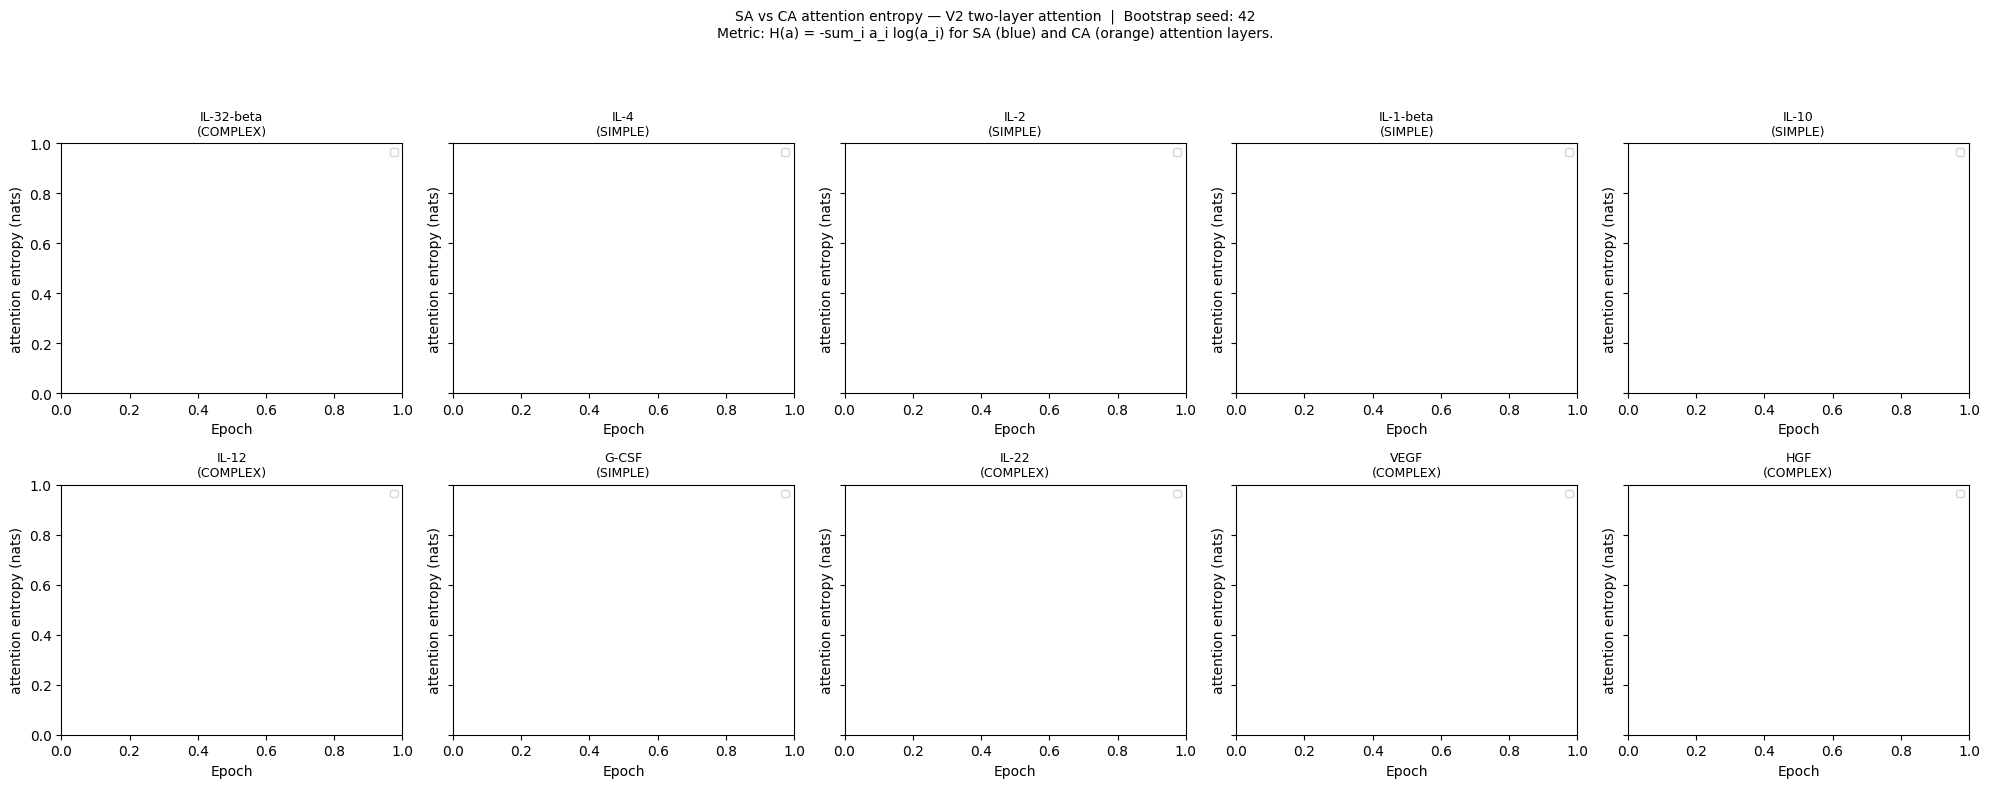

In [22]:
def _extract_layer_entropy(records, cytokine):
    """
    For each tube of the given cytokine, extract the SA and CA attention entropy
    trajectories stored in records.

    SA entropy is stored in 'entropy_trajectory'; CA entropy in 'entropy_trajectory_ca'.
    These differ because SA and CA attend to different cells with different specificity.

    Returns:
        sa_curves: list of (n_logged_epochs,) arrays, one per tube.
        ca_curves: list of (n_logged_epochs,) arrays, one per tube.
    """
    sa_curves, ca_curves = [], []
    for rec in records:
        if rec["cytokine"] != cytokine:
            continue
        sa_traj = rec.get("entropy_trajectory")
        ca_traj = rec.get("entropy_trajectory_ca")
        if sa_traj is None or ca_traj is None:
            continue
        sa_curves.append(np.array(sa_traj))   # (n_logged_epochs,)
        ca_curves.append(np.array(ca_traj))   # (n_logged_epochs,)
    return sa_curves, ca_curves


epochs = dynamics_stage2["logged_epochs"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for ax, (cytokine, _) in zip(axes, ranking_result["ranking"]):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    sa_curves, ca_curves = _extract_layer_entropy(
        dynamics_stage2["records"], cytokine
    )
    if sa_curves:
        mean_sa = np.mean(sa_curves, axis=0)
        mean_ca = np.mean(ca_curves, axis=0)
        ax.plot(epochs, mean_sa, color="steelblue",  linewidth=2, label="SA layer")
        ax.plot(epochs, mean_ca, color="darkorange", linewidth=2, label="CA layer", linestyle="--")
    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("attention entropy (nats)")
    ax.legend(fontsize=7)

fig.suptitle(
    f"SA vs CA attention entropy — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Metric: H(a) = -sum_i a_i log(a_i) for SA (blue) and CA (orange) attention layers.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"sa_vs_ca_entropy_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

### 2. Attention overlap score per cytokine

For each tube, compute:
```
overlap(t) = sum_i min(a_SA_i(t), a_CA_i(t))
```
- `overlap = 1` → SA and CA attend identically (fully redundant).
- `overlap = 0` → SA and CA attend to completely different cells (fully specialized).

Mean across tubes per cytokine, then across logged epochs.

**Metric:** `mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))` —
attention overlap score (0 = fully specialized, 1 = identical).

In [23]:
def _compute_attention_overlap(
    records,
    key_sa="confidence_trajectory_sa",
    key_ca="confidence_trajectory_ca",
):
    """
    Compute mean attention overlap score per cytokine across tubes and epochs.

    overlap(tube, t) = sum_i min(a_SA_i(t), a_CA_i(t))

    C_SA_i(t) = a_SA_i(t) * p_correct(t)  and similarly for CA.
    To recover a_SA_i(t) from C_SA_i(t) we divide by p_correct(t).
    Tubes/epochs where p_correct is zero are skipped.

    Returns:
        overlap_per_cytokine: {cytokine -> float} mean overlap score.
        overlap_trajectory: {cytokine -> np.array(n_logged_epochs)} mean overlap over time.
    """
    raw = defaultdict(list)  # cytokine -> list of (n_logged_epochs,) arrays
    for rec in records:
        csa = rec.get(key_sa)
        cca = rec.get(key_ca)
        if csa is None or cca is None:
            continue
        # csa shape: (n_cells, n_logged_epochs)
        p_traj = np.array(rec["p_correct_trajectory"])  # (n_logged_epochs,)
        # Avoid division by zero; skip epochs where p_correct == 0.
        safe_p = np.where(p_traj > 1e-10, p_traj, np.nan)
        a_sa = csa / safe_p[np.newaxis, :]  # (n_cells, n_logged_epochs)
        a_ca = cca / safe_p[np.newaxis, :]  # (n_cells, n_logged_epochs)
        # sum_i min(a_SA_i, a_CA_i) for each epoch
        overlap_traj = np.nansum(
            np.minimum(a_sa, a_ca), axis=0
        )  # (n_logged_epochs,)
        raw[rec["cytokine"]].append(overlap_traj)

    overlap_per_cytokine = {}
    overlap_trajectory   = {}
    for cytokine, trajs in raw.items():
        stacked = np.stack(trajs, axis=0)            # (n_tubes, n_logged_epochs)
        mean_traj = np.nanmean(stacked, axis=0)      # (n_logged_epochs,)
        overlap_trajectory[cytokine]   = mean_traj
        overlap_per_cytokine[cytokine] = float(np.nanmean(mean_traj))
    return overlap_per_cytokine, overlap_trajectory


overlap_scores, overlap_trajs = _compute_attention_overlap(dynamics_stage2["records"])

print("Attention overlap score per cytokine")
print("Metric: mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))")
print("  0 = fully specialized (SA and CA attend to different cells)")
print("  1 = identical (SA and CA attend identically)")
print()
for cytokine, score in sorted(overlap_scores.items(), key=lambda x: x[1]):
    if cytokine == "PBS":
        continue
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    print(f"{cytokine:<20} {group:<10} overlap={score:.4f}")

Attention overlap score per cytokine
Metric: mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))
  0 = fully specialized (SA and CA attend to different cells)
  1 = identical (SA and CA attend identically)

IL-32-beta           COMPLEX    overlap=0.0138
IL-10                SIMPLE     overlap=0.0273
IL-22                COMPLEX    overlap=0.0412
G-CSF                SIMPLE     overlap=0.0424
IL-1-beta            SIMPLE     overlap=0.0465
HGF                  COMPLEX    overlap=0.0503
VEGF                 COMPLEX    overlap=0.0504
IL-2                 SIMPLE     overlap=0.0682
IL-12                COMPLEX    overlap=0.0827
IL-4                 SIMPLE     overlap=0.0931


### 3. Attention overlap trajectories over training

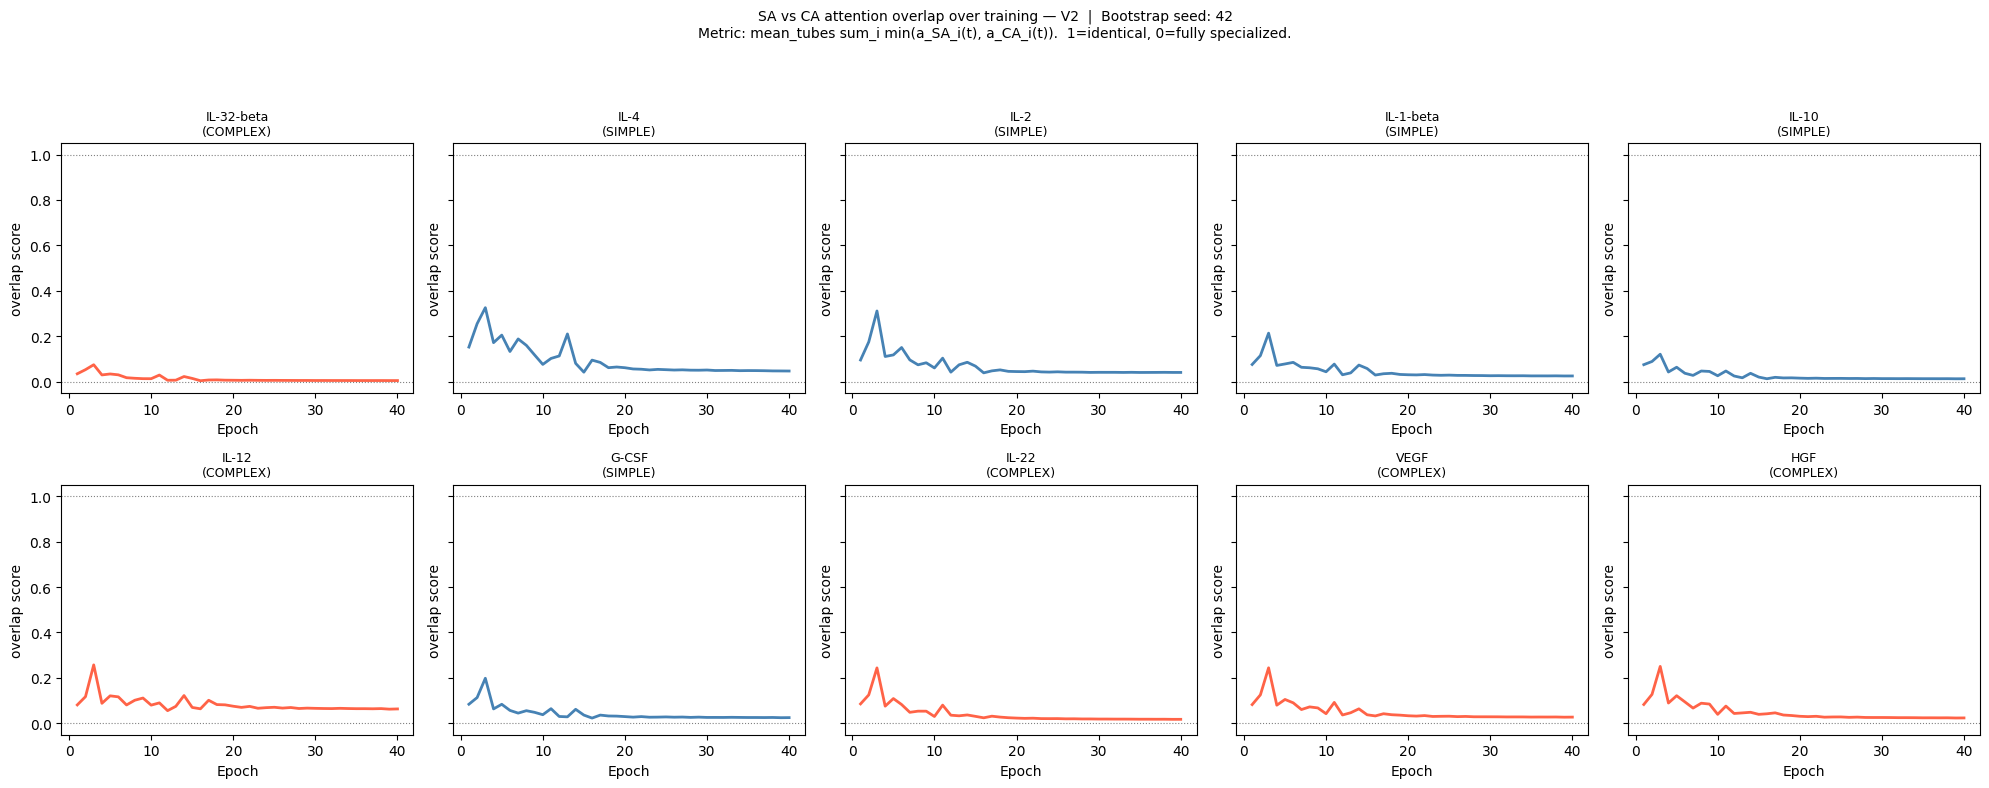

In [24]:
epochs = dynamics_stage2["logged_epochs"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for ax, (cytokine, _) in zip(axes, ranking_result["ranking"]):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    color = GROUP_COLOR[group]
    traj = overlap_trajs.get(cytokine)
    if traj is not None and len(traj) == len(epochs):
        ax.plot(epochs, traj, color=color, linewidth=2)
        ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, label="identical")
        ax.axhline(0.0, color="gray", linestyle=":", linewidth=0.8, label="fully specialized")
    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("overlap score")

fig.suptitle(
    f"SA vs CA attention overlap over training — V2  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Metric: mean_tubes sum_i min(a_SA_i(t), a_CA_i(t)).  1=identical, 0=fully specialized.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"attention_overlap_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()